In [14]:
# El script establece la ruta para cargar el conjunto de datos.
ruta_archivo = os.path.join(r"C:\Users\patri\Downloads", "fifa_eda.csv")

# La instrucción carga el archivo ajustando la codificación para reparar los caracteres especiales.
df = pd.read_csv(ruta_archivo, encoding='utf-8', dtype={'ITEM_CODE': str})


In [3]:
# El script establece la ruta para cargar el conjunto de datos.
ruta_archivo = os.path.join(r"C:\Users\patri\Downloads", "fifa_eda.csv")

# La instrucción carga el archivo con los parámetros indicados.
df = pd.read_csv(ruta_archivo, encoding='latin1', dtype={'ITEM_CODE': str})

# 1. Para ver los datos
print(df.head())
# 2. Para ver los nombres EXACTOS de las columnas (sin recortes)
print(df.columns.tolist())

       ID               Name  Age Nationality  Overall  Potential  \
0  158023           L. Messi   31   Argentina       94         94   
1   20801  Cristiano Ronaldo   33    Portugal       94         94   
2  190871          Neymar Jr   26      Brazil       92         93   
3  193080             De Gea   27       Spain       91         93   
4  192985       K. De Bruyne   27     Belgium       91         92   

                  Club      Value   Wage Preferred Foot  \
0         FC Barcelona 110,500.00 565.00           Left   
1             Juventus  77,000.00 405.00          Right   
2  Paris Saint-Germain 118,500.00 290.00          Right   
3    Manchester United  72,000.00 260.00          Right   
4      Manchester City 102,000.00 355.00          Right   

   International Reputation  Skill Moves Position  Joined  \
0                      5.00         4.00       RF    2004   
1                      5.00         5.00       ST    2018   
2                      5.00         5.00       

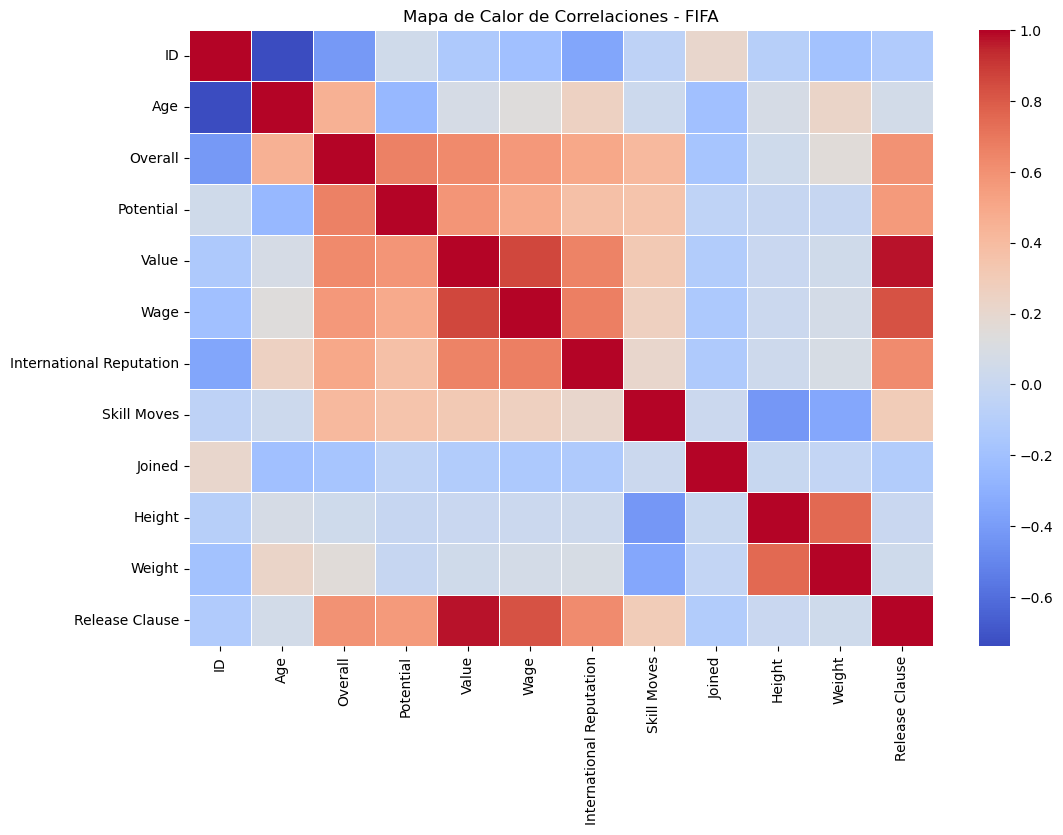

In [4]:
# El proceso aísla las variables numéricas para generar la matriz.
plt.figure(figsize=(12, 8))
cols_numericas = df.select_dtypes(include=['float64', 'int64'])
matriz_corr = cols_numericas.corr()

# La librería dibuja el mapa de calor.
sns.heatmap(matriz_corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones - FIFA')
plt.show()

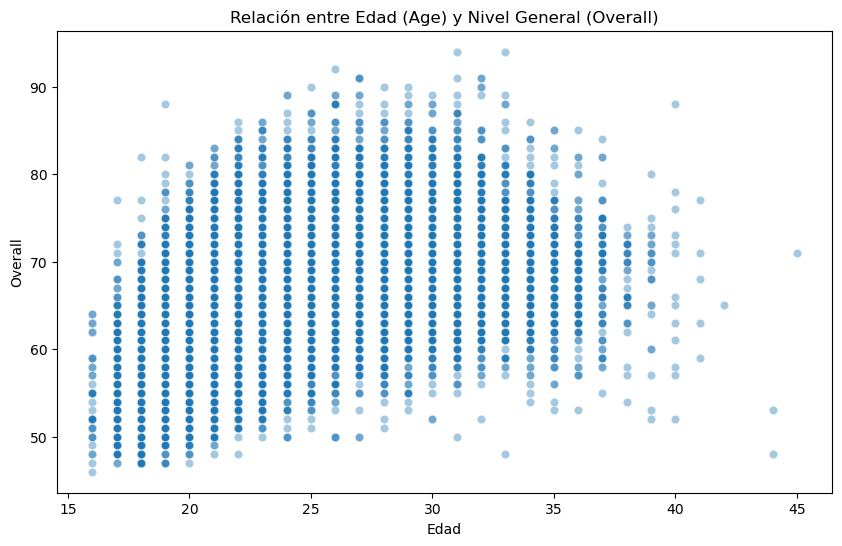

In [5]:
# El fragmento genera un diagrama de dispersión para observar la relación.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Overall', alpha=0.4)
plt.title('Relación entre Edad (Age) y Nivel General (Overall)')
plt.xlabel('Edad')
plt.ylabel('Overall')
plt.show()

## El gráfico muestra que el overall tiende a subir a medida que el jugador madura, alcanzando su punto máximo entre los 26 y 31 años. Después de esa edad, se observa un declive gradual en la valoración general.

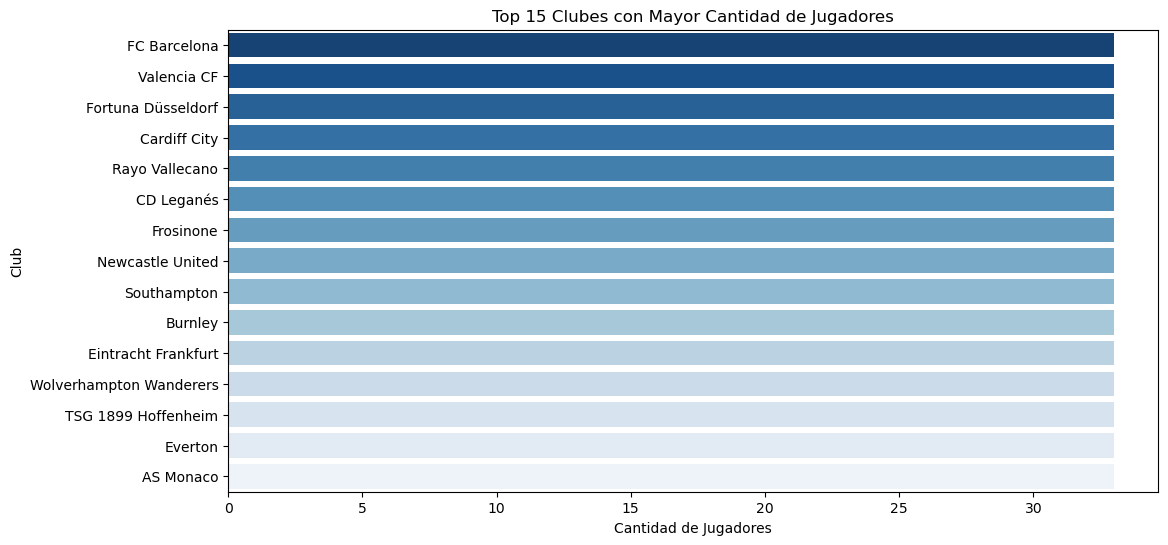

In [15]:
# El bloque filtra los 15 clubes con más jugadores para que el gráfico sea legible.
plt.figure(figsize=(12, 6))
top_clubes = df['Club'].value_counts().head(15)

# La función dibuja el gráfico asignando el eje y al parámetro hue para evitar advertencias.
sns.barplot(
    x=top_clubes.values, 
    y=top_clubes.index, 
    hue=top_clubes.index, 
    palette='Blues_r', 
    legend=False
)
plt.title('Top 15 Clubes con Mayor Cantidad de Jugadores')
plt.xlabel('Cantidad de Jugadores')
plt.ylabel('Club')
plt.show()

## En el dataset de FIFA, la mayoría de los equipos de primera división tienen un límite estricto de jugadores registrados en su plantilla, que en este archivo es exactamente de 33 jugadores.

### Al pedirle al código que traiga los 15 primeros (head(15)), simplemente está mostrando a 15 de los muchos equipos que están "empatados" en el primer lugar con el tope máximo de jugadores. El gráfico es matemáticamente correcto, solo que los datos en la cima no tienen variación.

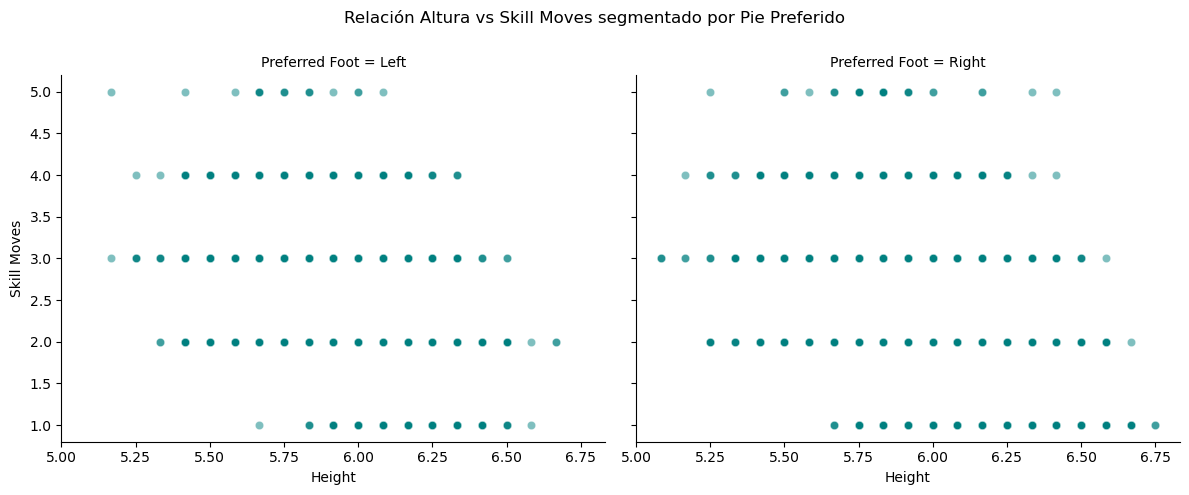

In [8]:
# El método mapea la relación dividiendo el gráfico por pie preferido.
grafico_panel = sns.FacetGrid(df, col="Preferred Foot", height=5, aspect=1.2)
grafico_panel.map(sns.scatterplot, "Height", "Skill Moves", alpha=0.5, color='teal')
grafico_panel.fig.subplots_adjust(top=0.85)
grafico_panel.fig.suptitle('Relación Altura vs Skill Moves segmentado por Pie Preferido')
plt.show()

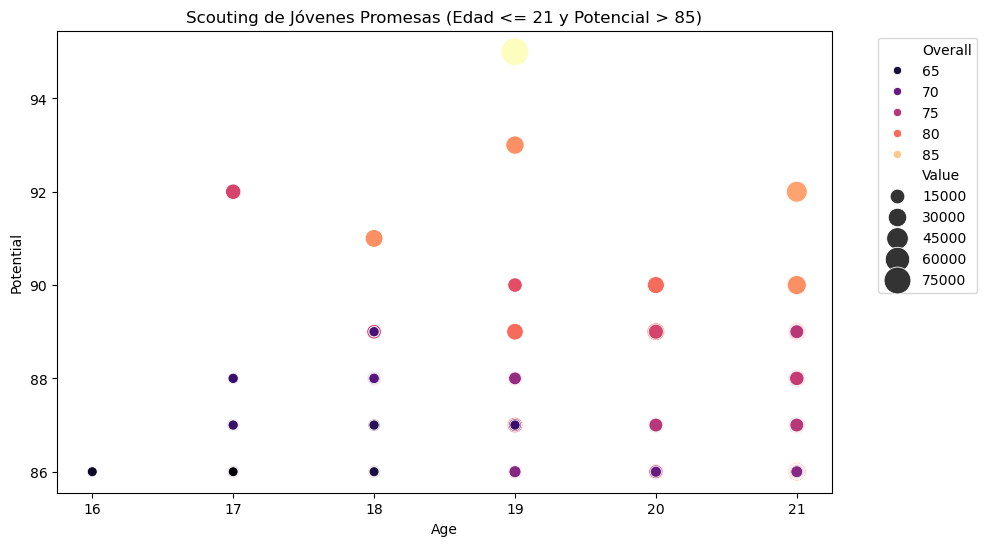

In [9]:
# El código filtra a los jugadores de 21 años o menos que tienen un potencial mayor a 85.
plt.figure(figsize=(10, 6))
cracks = df[(df['Age'] <= 21) & (df['Potential'] > 85)]

# La gráfica muestra el potencial frente a la edad, destacando en color su overall actual.
sns.scatterplot(
    data=cracks, 
    x='Age', 
    y='Potential', 
    hue='Overall', 
    size='Value', 
    sizes=(50, 400), 
    palette='magma'
)
plt.title('Scouting de Jóvenes Promesas (Edad <= 21 y Potencial > 85)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()